# ADMM Residuals Plotting

This notebook plots primal and dual residuals from ADMM iteration output files.

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [97]:
def parse_padmm_file(filename):
    """
    Parse PADMM output file and extract iteration data.
    
    PADMM files have a format where multiple iterations can appear on a single line.
    Each iteration has 7 columns: Iter, Time, Objective, Prml Rsdl, Dual Rsdl, SNR, distance
    
    Returns:
        iterations: array of iteration numbers
        objectives: array of objective values
        primal_residuals: array of primal residuals
        dual_residuals: array of dual residuals
        snr: array of SNR values
        distance: array of distance values
    """
    iterations = []
    objectives = []
    primal_residuals = []
    dual_residuals = []
    snr = []
    distance = []
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Find the header line
    header_found = False
    for i, line in enumerate(lines):
        if 'Iter' in line and 'Prml Rsdl' in line and 'Dual Rsdl' in line:
            header_found = True
            # Skip the separator line
            start_idx = i + 2
            break
    
    if not header_found:
        raise ValueError("Could not find header line in file")
    
    # Parse data lines
    for line in lines[start_idx:]:
        line = line.strip()
        
        # Skip empty lines
        if not line:
            continue
        
        # Skip lines that look like summary/end messages (e.g., "TV Restruction", "SNR:")
        if line.startswith('TV') or line.startswith('SNR:') or 'Restruction' in line:
            continue
        
        # Split the line into parts
        parts = line.split()
        
        # Each iteration has 7 columns: Iter, Time, Objective, Prml Rsdl, Dual Rsdl, SNR, distance
        # Process all iterations on this line (multiple iterations can be on one line)
        num_iterations = len(parts) // 7
        
        # Process each complete iteration (7 columns each)
        for i in range(num_iterations):
            start_col = i * 7
            end_col = start_col + 7
            
            if end_col > len(parts):
                break
            
            try:
                iter_parts = parts[start_col:end_col]
                
                # Column 0: iteration number
                iter_num = int(iter_parts[0])
                
                # Column 2: objective
                obj_str = iter_parts[2]
                if obj_str.lower() == 'inf':
                    obj = np.inf
                else:
                    obj = float(obj_str)
                
                # Column 3: primal residual
                primal = float(iter_parts[3])
                
                # Column 4: dual residual
                dual = float(iter_parts[4])
                
                # Column 5: SNR
                snr_val = float(iter_parts[5])
                
                # Column 6: distance
                dist_val = float(iter_parts[6])
                
                iterations.append(iter_num)
                objectives.append(obj)
                primal_residuals.append(primal)
                dual_residuals.append(dual)
                snr.append(snr_val)
                distance.append(dist_val)
                
            except (ValueError, IndexError) as e:
                # Skip this iteration if parsing fails
                continue
    
    return (np.array(iterations), np.array(objectives), np.array(primal_residuals), 
            np.array(dual_residuals), np.array(snr), np.array(distance))

In [98]:
def parse_admm_file(filename):
    """
    Parse ADMM output file and extract iteration data.
    
    Returns:
        iterations: array of iteration numbers
        objectives: array of objective values
        primal_residuals: array of primal residuals
        dual_residuals: array of dual residuals
        regularization: array of regularization term values
        constraint: array of constraint term values
    """
    iterations = []
    objectives = []
    primal_residuals = []
    dual_residuals = []
    regularization = []
    constraint = []
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Find the header line
    header_found = False
    for i, line in enumerate(lines):
        if 'Iter' in line and 'Prml Rsdl' in line and 'Dual Rsdl' in line:
            header_found = True
            # Skip the separator line
            start_idx = i + 2
            break
    
    if not header_found:
        raise ValueError("Could not find header line in file")
    
    # Parse data lines
    for line in lines[start_idx:]:
        line = line.strip()
        
        # Skip empty lines and "τ is doubled" messages
        if not line or 'τ is doubled' in line:
            continue
        
        # Try to parse the line as a data row
        # Format: "  73  8.91e+01  4.755e+05  7.899e+03  3.760e+02  7.878e+03  1.220e+03"
        # Column order: Iter, Time, Objective, Prml Rsdl, Dual Rsdl, Regularization, Constraint
        parts = line.split()
        
        if len(parts) >= 5:
            try:
                # Column 0: iteration, Column 2: objective, Column 3: primal residual, Column 4: dual residual
                iter_num = int(parts[0])
                # Handle 'inf' for objective
                obj_str = parts[2]
                if obj_str.lower() == 'inf':
                    obj = np.inf
                else:
                    obj = float(obj_str)
                primal = float(parts[3])
                dual = float(parts[4])
                
                iterations.append(iter_num)
                objectives.append(obj)
                primal_residuals.append(primal)
                dual_residuals.append(dual)
                
                # Extract regularization and constraint if available (columns 5 and 6)
                if len(parts) >= 7:
                    regularization.append(float(parts[5]))
                    constraint.append(float(parts[6]))
                else:
                    regularization.append(np.nan)
                    constraint.append(np.nan)
            except (ValueError, IndexError):
                # Skip lines that don't match the expected format
                continue
    
    return np.array(iterations), np.array(objectives), np.array(primal_residuals), np.array(dual_residuals), np.array(regularization), np.array(constraint)

## Configuration

Specify the path to your ADMM output file:

In [99]:
# Update this path to point to your ADMM output file
SNR = "inf"
num_views = "100"
rho = "5e-1"
regularization_coeff = "2e0"
maxiter = "10000"
regularization_type = "tv"
downsample_factor = 4
save = False
maxiter_pdhg = 50
row_division_num = 2
col_division_num = 2

input_file = f"results/semi_pjadmm_parallel_{regularization_type}_fbp_recon_nanolaminography_sinogram_snr{SNR}_{row_division_num}_{col_division_num}_l2_plus_reg_iterative_reg_downsampled_factor_{downsample_factor}/ct_mbirjax_3d_{regularization_type}_semi_pjadmm_parallel_fbp_recon_nanolaminography_sinogram_snr{SNR}_ρ{rho}_regularization{regularization_coeff}_n_projection{num_views}_maxiter{maxiter}_maxiter_pdhg{maxiter_pdhg}_iterative_reg.txt"

## Parse Data

In [100]:
print(f"Parsing file: {input_file}")
iterations, objectives, primal_residuals, dual_residuals, regularization, constraint = parse_admm_file(input_file)

Parsing file: results/semi_pjadmm_parallel_tv_fbp_recon_nanolaminography_sinogram_snrinf_2_2_l2_plus_reg_iterative_reg_downsampled_factor_4/ct_mbirjax_3d_tv_semi_pjadmm_parallel_fbp_recon_nanolaminography_sinogram_snrinf_ρ5e-1_regularization2e0_n_projection100_maxiter10000_maxiter_pdhg50_iterative_reg.txt


In [101]:
# Moving average for smoother residual plots (adjust window to taste)
def moving_average(x, window):
    """Uniform moving average; same length as x (boundary uses partial window)."""
    return np.convolve(x, np.ones(window) / window, mode="same")

In [102]:
smooth_window = 100
primal_residuals_smooth = moving_average(primal_residuals, smooth_window)
dual_residuals_smooth = moving_average(dual_residuals, smooth_window)

## Plot Residuals

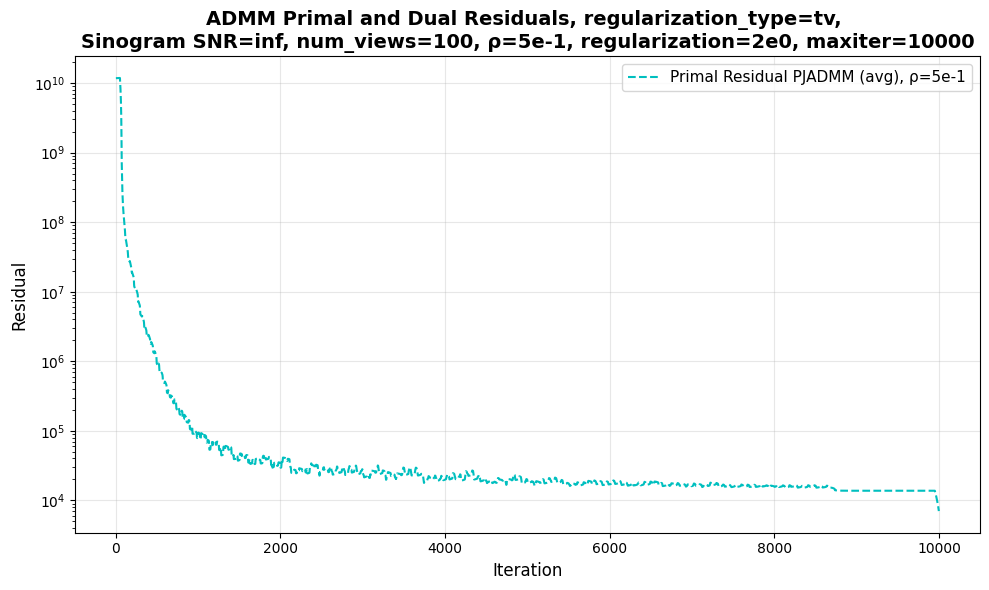

In [103]:
# Plot Residuals (smoothed with moving average to reduce oscillation)
plt.figure(figsize=(10, 6))

'''
PJADMM Part
'''
plt.semilogy(iterations[1:], primal_residuals_smooth[1:], 'c--', label=f'Primal Residual PJADMM (avg), ρ={rho}', linewidth=1.5)

'''
Plot Configs
'''
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.title(f'ADMM Primal and Dual Residuals, regularization_type={regularization_type}, \nSinogram SNR={SNR}, num_views={num_views}, ρ={rho}, regularization={regularization_coeff}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Set y-axis ticks to be every 10^n
from matplotlib.ticker import LogLocator
ax = plt.gca()
plt.tight_layout()

if save:
    output_file = f"results/residual_plots/semi_pjadmm_residuals_regularization_type{regularization_type}_Nx{Nx}_Ny{Ny}_Nz{Nz}_snr{SNR}_num_views{num_views}_rho{rho}_regularization{regularization_coeff}_maxiter{maxiter}_l2_plus_reg.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

plt.show()

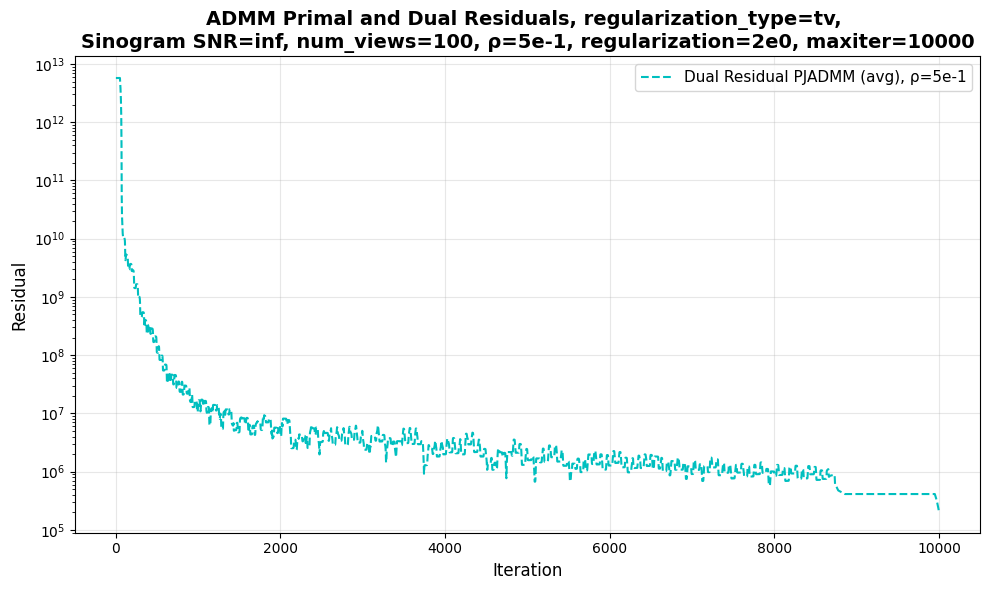

In [104]:
# Plot Residuals (smoothed with moving average to reduce oscillation)
plt.figure(figsize=(10, 6))

'''
PJADMM Part
'''
plt.semilogy(iterations[1:], dual_residuals_smooth[1:], 'c--', label=f'Dual Residual PJADMM (avg), ρ={rho}', linewidth=1.5)

'''
Plot Configs
'''
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.title(f'ADMM Primal and Dual Residuals, regularization_type={regularization_type}, \nSinogram SNR={SNR}, num_views={num_views}, ρ={rho}, regularization={regularization_coeff}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Set y-axis ticks to be every 10^n
from matplotlib.ticker import LogLocator
ax = plt.gca()
plt.tight_layout()

if save:
    output_file = f"results/residual_plots/semi_pjadmm_residuals_regularization_type{regularization_type}_Nx{Nx}_Ny{Ny}_Nz{Nz}_snr{SNR}_num_views{num_views}_rho{rho}_regularization{regularization_coeff}_maxiter{maxiter}_l2_plus_reg.png"
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {output_file}")

plt.show()

In [13]:
import numpy as np
example_result = np.load('/home/zhengtan/repos/scico/examples/scripts/results/semi_pjadmm_parallel_tv_fbp_recon_nanolaminography_sinogram_snrinf_2_2_l2_plus_reg_iterative_reg_downsampled_factor_4/ct_mbirjax_3d_tv_semi_pjadmm_parallel_fbp_recon_nanolaminography_100views_ρ0.5_τ0.1_regularization2.0_maxiter10000_maxiter_pdhg50_iterative_reg_estimated_pdhg.npy')
Nz, Ny, Nx = example_result.shape

# Create the projector and the full sinogram
angles = np.linspace(0, np.pi, 100, endpoint=False)  # evenly spaced projection angles
sinogram_shape = (Nz, 100, max(Nx, Ny))
from scico.linop.xray.mbirjax import XRayTransformParallel

A_full = XRayTransformParallel(
    output_shape=sinogram_shape,
    angles=angles,
    recon_shape=(Nx, Ny, Nz)
)
sinogram = A_full @ example_result        # The sinogram is stored onto the first GPU.

print(np.linalg.norm(sinogram))

1.9387749e+11


NameError: name 'true_regularization' is not defined

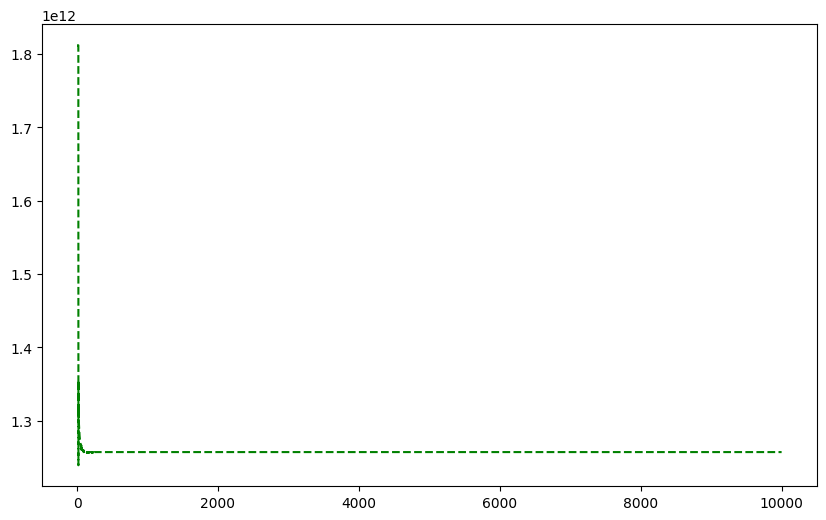

In [105]:
plt.figure(figsize=(10, 6))
start_index = 1

# Filter out inf values for plotting
valid_mask = (objectives != np.inf) & (objectives > 0)
# valid_mask_padmm = (objectives_padmm != np.inf) & (objectives_padmm > 0)

plt.plot(iterations[valid_mask][start_index:], regularization[valid_mask][start_index:], 'g--', label='Regularization', linewidth=1.5)
# plt.plot(iterations_padmm[valid_mask_padmm][start_index:], regularization_padmm[valid_mask_padmm][start_index:], 'b--', label='Regularization PADMM', linewidth=1.5)

plt.axhline(y=float(regularization_coeff) * true_regularization(x_gt), color='r', linestyle='-', label='True Regularization', linewidth=1.5)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title(f'ADMM Objective, Regularization, and Constraint, regularization_type={regularization_type}, \nSNR={SNR}, num_views={num_views}, ρ={rho}, regularization={regularization_coeff}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()

In [ ]:
plt.figure(figsize=(10, 6))
start_index = 50

true_constraint = 0.5 * np.linalg.norm(y_noisy - y)**2

# Filter out inf values for plotting
valid_mask = (objectives != np.inf) & (objectives > 0)
# valid_mask_padmm = (objectives_padmm != np.inf) & (objectives_padmm > 0)

plt.plot(iterations[valid_mask][start_index:], constraint[valid_mask][start_index:], 'g--', label='Constraint', linewidth=1.5)
# plt.plot(iterations_padmm[valid_mask_padmm][start_index:], constraint_padmm[valid_mask_padmm][start_index:], 'b--', label='Constraint PADMM', linewidth=1.5)

plt.axhline(y=true_constraint, color='r', linestyle='-', label='True Constraint', linewidth=1.5)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title(f'ADMM Objective, Regularization, and Constraint, regularization_type={regularization_type}, \nSNR={SNR}, num_views={num_views}, ρ={rho}, regularization={regularization_coeff}, maxiter={maxiter}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()